In [1]:
# Import libraries

import pandas as pd              
import numpy as np               
import matplotlib.pyplot as plt  
import seaborn as sns           

# To display plots properly
plt.style.use('seaborn-v0_8')

In [2]:
# Load the dataset

df = pd.read_csv("real.csv")

# Display first 5 rows
df.head()

,OBJECTID,PropertyID,xrCompositeLandUseID,xrBuildingTypeID,ParcelID,LocationStartNumber,ApartmentUnitNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,...,OwnerFirstName,PrimaryGrantor,SaleDate,SalePrice,TotalAppraisedValue,LegalReference,xrSalesValidityID,xrDeedID,AssrLandUse,GlobalID
0,1,8,3,6.0,121-698-063,77,NaN,STAFFORD ST,2,6000.0,...,LAKESHA,SCOTT NASTASSIA,2024/07/01 00:00:00+00,259000.0,187200,08275 0343,1,10,ONE FAMILY,{78B6AAB5-D21E-471C-85BE-022DAB2A80B7}
1,2,9,3,3.0,121-698-062,73,NaN,STAFFORD ST,2,6000.0,...,ARCADIO,DIAZ RAFAEL,2022/04/26 00:00:00+00,208000.0,192300,07948-0001,1,10,ONE FAMILY,{15F34650-E463-4047-8808-A056FCDA3E09}
2,3,12,3,6.0,144-698-066,61,NaN,STAFFORD ST,2,6000.0,...,CATIRIA,KERN THOMAS,2023/12/22 00:00:00+00,125000.0,148400,08197-0077,1,10,ONE FAMILY,{C6FCA409-022A-4F1B-A674-13996FD1FE86}
3,4,20,3,6.0,144-698-058,29,NaN,STAFFORD ST,2,6000.0,...,REBECA,RAMOS MIGUEL JR,2023/09/29 00:00:00+00,1.0,167300,08158 0179,5,8,ONE FAMILY,{4D1DDED3-EF58-4091-A5F1-C7CA38B38C74}
4,5,25,3,6.0,144-698-053,211,NaN,NEWINGTON AVE,2,5040.0,...,LOURDES,BAIJANATH BISSNOW P,2021/01/11 00:00:00+00,177000.0,197900,07701-0245,1,10,ONE FAMILY,{F2E9A7CC-96D2-47AE-A2C1-59745FBE9C9E}


In [3]:
# Display dataset shape (rows, columns)
print("Dataset Shape:", df.shape)

# Display column names
print("Columns:", df.columns)

# Display datatype information
df.info()

Dataset Shape: (7410, 23)
Columns: Index(['OBJECTID', 'PropertyID', 'xrCompositeLandUseID', 'xrBuildingTypeID',
       'ParcelID', 'LocationStartNumber', 'ApartmentUnitNumber',
       'StreetNameAndWay', 'xrPrimaryNeighborhoodID', 'LandSF',
       'TotalFinishedArea', 'LivingUnits', 'OwnerLastName', 'OwnerFirstName',
       'PrimaryGrantor', 'SaleDate', 'SalePrice', 'TotalAppraisedValue',
       'LegalReference', 'xrSalesValidityID', 'xrDeedID', 'AssrLandUse',
       'GlobalID'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7410 entries, 0 to 7409
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   OBJECTID                 7410 non-null   int64  
 1   PropertyID               7410 non-null   int64  
 2   xrCompositeLandUseID     7410 non-null   int64  
 3   xrBuildingTypeID         7409 non-null   float64
 4   ParcelID                 7410 non-null   object 
 5   Loc

In [4]:
# Check missing values in each column

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
OBJECTID                      0
PropertyID                    0
xrCompositeLandUseID          0
xrBuildingTypeID              1
ParcelID                      0
LocationStartNumber           0
ApartmentUnitNumber        5472
StreetNameAndWay              0
xrPrimaryNeighborhoodID       0
LandSF                     1931
TotalFinishedArea           173
LivingUnits                   1
OwnerLastName                 0
OwnerFirstName             2895
PrimaryGrantor                1
SaleDate                      0
SalePrice                   339
TotalAppraisedValue           0
LegalReference                1
xrSalesValidityID             0
xrDeedID                      0
AssrLandUse                   0
GlobalID                      0
dtype: int64


In [5]:
# Drop unnecessary columns

df = df.drop(columns=['OBJECTID', 'GlobalID', 'LegalReference'], errors='ignore')

# Check columns again
df.columns

Index(['PropertyID', 'xrCompositeLandUseID', 'xrBuildingTypeID', 'ParcelID',
       'LocationStartNumber', 'ApartmentUnitNumber', 'StreetNameAndWay',
       'xrPrimaryNeighborhoodID', 'LandSF', 'TotalFinishedArea', 'LivingUnits',
       'OwnerLastName', 'OwnerFirstName', 'PrimaryGrantor', 'SaleDate',
       'SalePrice', 'TotalAppraisedValue', 'xrSalesValidityID', 'xrDeedID',
       'AssrLandUse'],
      dtype='object')

In [7]:
# Fill numeric missing values with median

numeric_cols = df.select_dtypes(include=['int64','float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical missing values with mode

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
df

,PropertyID,xrCompositeLandUseID,xrBuildingTypeID,ParcelID,LocationStartNumber,ApartmentUnitNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,LivingUnits,OwnerLastName,OwnerFirstName,PrimaryGrantor,SaleDate,SalePrice,TotalAppraisedValue,xrSalesValidityID,xrDeedID,AssrLandUse
0,8,3,6.0,121-698-063,77,0002,STAFFORD ST,2,6000.0,1092.00000,1.0,WRIGHT,LAKESHA,SCOTT NASTASSIA,2024/07/01 00:00:00+00,259000.0,187200,1,10,ONE FAMILY
1,9,3,3.0,121-698-062,73,0002,STAFFORD ST,2,6000.0,936.00000,1.0,SANTANA,ARCADIO,DIAZ RAFAEL,2022/04/26 00:00:00+00,208000.0,192300,1,10,ONE FAMILY
2,12,3,6.0,144-698-066,61,0002,STAFFORD ST,2,6000.0,1111.00000,1.0,MARTINEZ,CATIRIA,KERN THOMAS,2023/12/22 00:00:00+00,125000.0,148400,1,10,ONE FAMILY
3,20,3,6.0,144-698-058,29,0002,STAFFORD ST,2,6000.0,1096.00000,1.0,RAMOS,REBECA,RAMOS MIGUEL JR,2023/09/29 00:00:00+00,1.0,167300,5,8,ONE FAMILY
4,25,3,6.0,144-698-053,211,0002,NEWINGTON AVE,2,5040.0,1684.00000,1.0,CAHUANA FLORES,LOURDES,BAIJANATH BISSNOW P,2021/01/11 00:00:00+00,177000.0,197900,1,10,ONE FAMILY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7405,29769,7,18.0,161-503-064,98,B,BROOKFIELD ST,512,0.0,1668.80001,1.0,BURGOS,TAMMIE,ABEL QUALITY CONSTRUCTION LLC,2024/04/22 00:00:00+00,315000.0,249500,1,10,CONDOMINIMUM
7406,29769,7,18.0,161-503-064,98,B,BROOKFIELD ST,512,0.0,1668.80001,1.0,BURGOS,TAMMIE,ABEL QUALITY CONSTRUCTION LLC,2024/05/17 00:00:00+00,0.0,249500,5,18,CONDOMINIMUM
7407,29769,7,18.0,161-503-064,98,B,BROOKFIELD ST,512,0.0,1668.80001,1.0,BURGOS,TAMMIE,BURGOS ISAAC,2024/08/26 00:00:00+00,0.0,249500,5,8,CONDOMINIMUM
7408,29770,7,18.0,161-503-065,98,C,BROOKFIELD ST,512,0.0,1676.80001,1.0,CRUZ MAZZINI,EDUARDO,ABEL QUALITY CONSTRUCTION LLC,2024/04/22 00:00:00+00,315000.0,249800,1,10,CONDOMINIMUM


In [8]:
# Convert SaleDate to datetime

df['SaleDate'] = pd.to_datetime(df['SaleDate'], errors='coerce')

# Extract year and month

df['SaleYear'] = df['SaleDate'].dt.year
df['SaleMonth'] = df['SaleDate'].dt.month


In [9]:
# Remove extreme outliers using IQR method

Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['SalePrice'] >= lower) & (df['SalePrice'] <= upper)]

In [11]:
# Select numerical columns for scaling
from sklearn.preprocessing import StandardScaler
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

# Remove target column from scaling
numeric_cols = numeric_cols.drop('SalePrice')

# Initialize scaler
scaler = StandardScaler()

# Apply scaling

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Display dataset after scaling
df.head()

/var/folders/88/lblxy3k91z7_q9wb10tzm99h0000gn/T/ipykernel_4297/464147902.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


,PropertyID,xrCompositeLandUseID,xrBuildingTypeID,ParcelID,LocationStartNumber,ApartmentUnitNumber,StreetNameAndWay,xrPrimaryNeighborhoodID,LandSF,TotalFinishedArea,...,OwnerFirstName,PrimaryGrantor,SaleDate,SalePrice,TotalAppraisedValue,xrSalesValidityID,xrDeedID,AssrLandUse,SaleYear,SaleMonth
0,-1.685103,-0.141412,-0.811446,121-698-063,-0.336152,0002,STAFFORD ST,-1.303622,-0.336594,-0.308843,...,LAKESHA,SCOTT NASTASSIA,2024-07-01 00:00:00+00:00,259000.0,-0.013026,-0.868371,0.426477,ONE FAMILY,2024,7
1,-1.684954,-0.141412,-1.431337,121-698-062,-0.352642,0002,STAFFORD ST,-1.303622,-0.336594,-0.350926,...,ARCADIO,DIAZ RAFAEL,2022-04-26 00:00:00+00:00,208000.0,0.006850,-0.868371,0.426477,ONE FAMILY,2022,4
2,-1.684506,-0.141412,-0.811446,144-698-066,-0.402110,0002,STAFFORD ST,-1.303622,-0.336594,-0.303717,...,CATIRIA,KERN THOMAS,2023-12-22 00:00:00+00:00,125000.0,-0.164238,-0.868371,0.426477,ONE FAMILY,2023,12
3,-1.683311,-0.141412,-0.811446,144-698-058,-0.534026,0002,STAFFORD ST,-1.303622,-0.336594,-0.307763,...,REBECA,RAMOS MIGUEL JR,2023-09-29 00:00:00+00:00,1.0,-0.090580,-0.417671,-0.371621,ONE FAMILY,2023,9
4,-1.682564,-0.141412,-0.811446,144-698-053,0.216246,0002,NEWINGTON AVE,-1.303622,-0.560602,-0.149140,...,LOURDES,BAIJANATH BISSNOW P,2021-01-11 00:00:00+00:00,177000.0,0.028674,-0.868371,0.426477,ONE FAMILY,2021,1


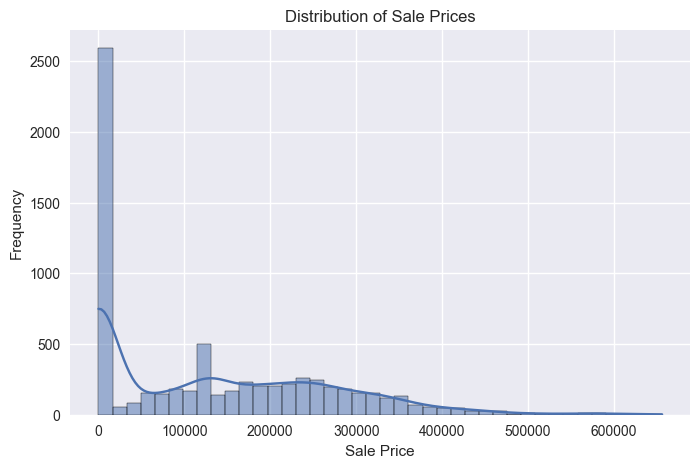

In [12]:
# Histogram for sale prices

plt.figure(figsize=(8,5))

sns.histplot(df['SalePrice'], bins=40, kde=True)

plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

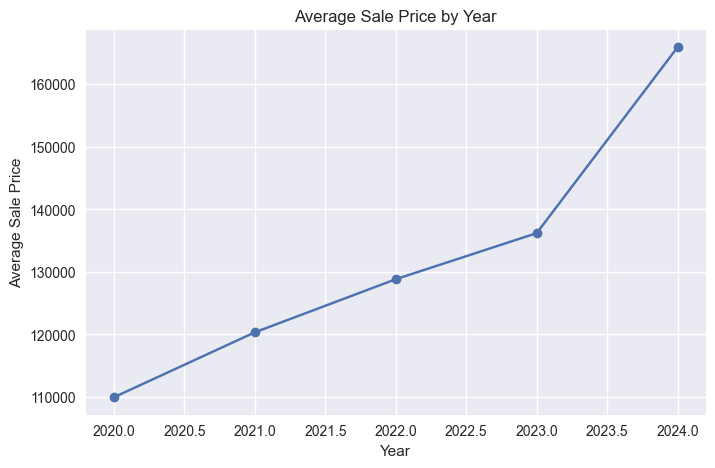

In [13]:
# Calculate average sale price per year

price_year = df.groupby('SaleYear')['SalePrice'].mean()

plt.figure(figsize=(8,5))

price_year.plot(kind='line', marker='o')

plt.title("Average Sale Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Sale Price")

plt.show()

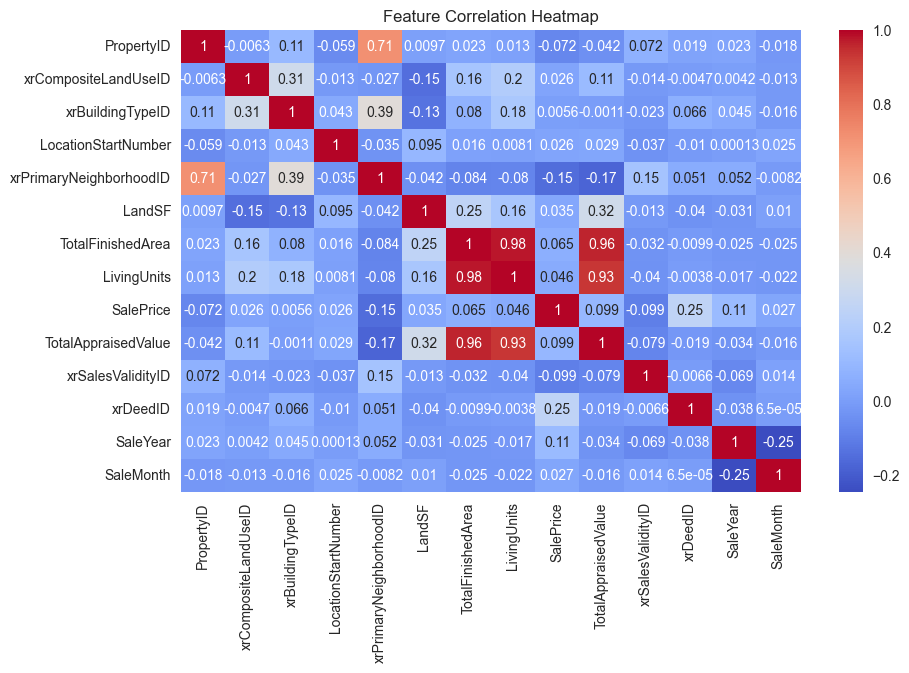

In [14]:
# Correlation heatmap

plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

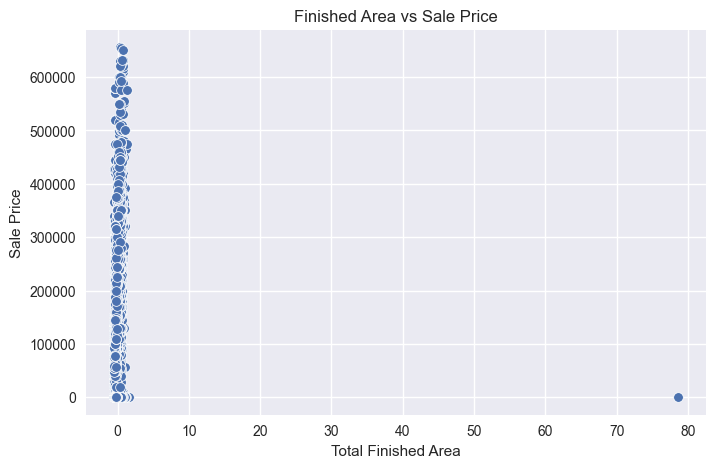

In [15]:
# Relationship between finished area and sale price

plt.figure(figsize=(8,5))

sns.scatterplot(x=df['TotalFinishedArea'],
                y=df['SalePrice'])

plt.title("Finished Area vs Sale Price")
plt.xlabel("Total Finished Area")
plt.ylabel("Sale Price")

plt.show()

In [16]:
# Save the preprocessed dataset

df.to_csv("real.csv", index=False)

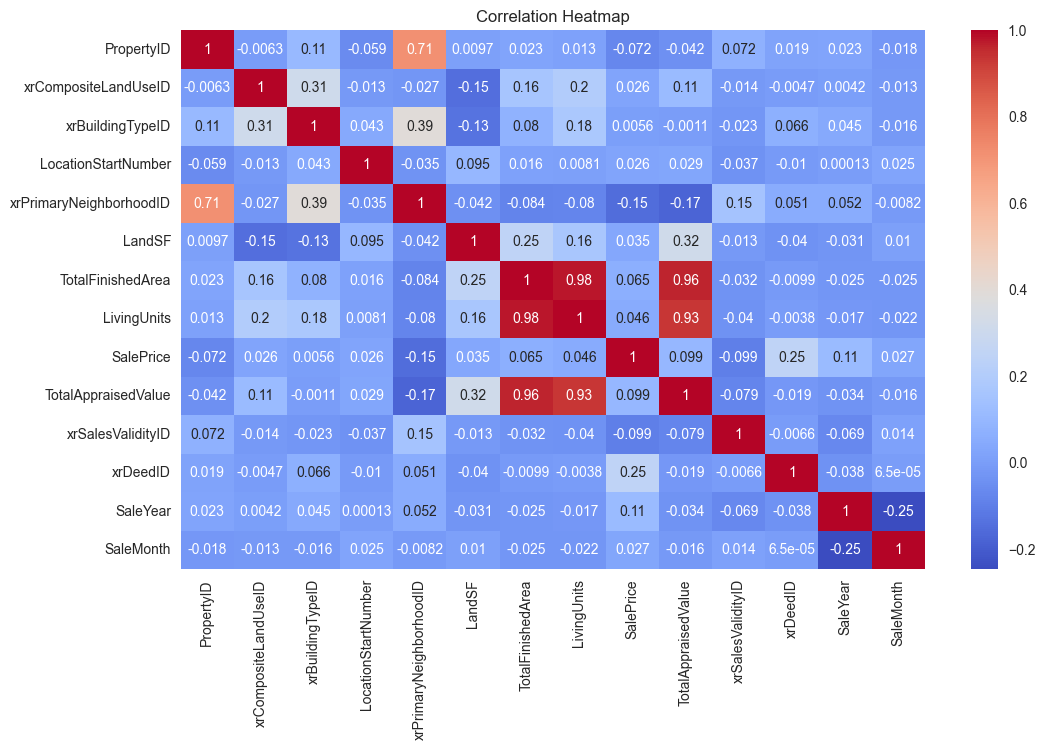

In [17]:
# Compute correlation matrix

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,7))

sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [18]:
# Compute correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Display matrix
print(corr_matrix)

                         PropertyID  xrCompositeLandUseID  xrBuildingTypeID  \
PropertyID                 1.000000             -0.006311          0.105998   
xrCompositeLandUseID      -0.006311              1.000000          0.310904   
xrBuildingTypeID           0.105998              0.310904          1.000000   
LocationStartNumber       -0.058611             -0.013095          0.042538   
xrPrimaryNeighborhoodID    0.713282             -0.026887          0.393729   
LandSF                     0.009684             -0.147617         -0.133811   
TotalFinishedArea          0.022699              0.159049          0.079818   
LivingUnits                0.012705              0.197312          0.175400   
SalePrice                 -0.072292              0.026157          0.005625   
TotalAppraisedValue       -0.042171              0.113693         -0.001087   
xrSalesValidityID          0.071780             -0.013669         -0.023295   
xrDeedID                   0.019127             -0.0